## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import random

In [2]:
real_or_simulated = 'real' #simulated / real / all
keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
augmentation = False
augmentation_weights = [0.9, 0.1]
proportion_of_augmented = 0.25

if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'

1) próbki razem + trzymanie jakiegoś id
2) czyszczenie danych
3) train-test split
4) augmentacja
5) normalizacja
6) przedziały ufności

## Loading the data

In [3]:
data_path = '../data/DANE.xlsx'
figures_path = '../results/visualisations/'

In [4]:
df = pd.ExcelFile(data_path)
if real_or_simulated == 'simulated':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
elif real_or_simulated == 'real':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
elif real_or_simulated == 'all':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list) #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

## Preprocessing

### Joining corresponding samples from inds and inks into one table

In [5]:
inks_df = inks_df.reset_index(drop=False)

In [6]:
inds_df = inds_df.reset_index(drop=False)

In [7]:
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inks', lsuffix='_inds')

In [8]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df[['nazwa próbki_inds', 'nazwa próbki_inks']][
#                 (inDKs_df['nazwa próbki_inds'].apply(
#                         lambda x: x[:4]) != inDKs_df['nazwa próbki_inks'].apply(
#                                         lambda x: x[:4]))
#                                                         ])

### Keeping track of the records from the same sample

In [9]:
inDKs_df['Sample_id'] = np.repeat(range(int(inDKs_df.shape[0]/15)), 15, axis=0)

### Removing some data

1. Let's remove rows with missing values.

In [10]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.047337278106508875

In [11]:
inDKs_df.dropna(inplace=True)

2. Let's keep only columns that we need.

In [12]:
inks_colnames = [col for col in inDKs_df.columns if (col.endswith('_inks') and 
                                                     col != 'nazwa próbki_inks'and
                                                    col != 'seria_inks' and
                                                    col != 'Fe_inks')]
inds_colnames = [col for col in inDKs_df.columns if (col.endswith('_inds') and 
                                                     col != 'nazwa próbki_inds'and
                                                    col != 'seria_inds' and
                                                    col != 'Fe_inds')]
#no iron because it's a reference element

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

If you want to keep use version with 29 numbers, just comment out the cell below.

In [13]:
inks_colnames = [
 'Al_inks',
 'S_inks',
 'Cr_inks',
 'Mn_inks',
 'Co_inks',
 'Cu_inks',
 'Zn_inks',
 'Pb_inks']

inds_colnames = [
 'Al_inds',
 'S_inds',
 'Cr_inds',
 'Mn_inds',
 'Co_inds',
 'Cu_inds',
 'Zn_inds',
 'Pb_inds']

In [14]:
inDKs_df = inDKs_df[inks_colnames + inds_colnames + ['Sample_id']]

### Train test split, datasets, dataloaders

In [15]:
if keep_sample_together:
    indices = list(range(inDKs_df['Sample_id'].max()))
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    X_y_train = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_train)]
    X_y_val = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_val)]
    X_y_test = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_test)]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

else:
    indices = list(range(int(inDKs_df.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)
    
    partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}
    
    X_y_train = inDKs_df.iloc[partition['train'],:]
    X_y_val = inDKs_df.iloc[partition['val'],:]
    X_y_test = inDKs_df.iloc[partition['test'],:]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

In [16]:
# if augmentation:
#     X_train = torch.cat([X_train, X_aug])
#     y_train = torch.cat([y_train, y_aug])

### Data augmentation

In [17]:
if real_or_simulated == 'real' and augmentation:
    inks_df_sim = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df_sim = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
    inks_df_sim.reset_index(drop=False, inplace=True)
    inds_df_sim.reset_index(drop=False, inplace=True)
    inDKs_df_sim = inds_df_sim.join(inks_df_sim, how='inner', rsuffix='_inks', lsuffix='_inds')
    ids_sim = range(inDKs_df['Sample_id'].max()+1, inDKs_df['Sample_id'].max() + 1 + int(inDKs_df_sim.shape[0]/15))
    inDKs_df_sim['Sample_id'] = np.repeat(ids_sim, 15, axis=0)
    inDKs_df_sim.dropna(inplace=True)
    inDKs_df_sim = inDKs_df_sim[inks_colnames + inds_colnames + ['Sample_id']]

In [18]:
if real_or_simulated == 'real' and augmentation:
    indices_to_mix_real = random.sample(range(X_y_train.shape[0]), 
                                        int(np.floor(X_y_train.shape[0]*proportion_of_augmented)))
    indices_to_mix_sim = random.sample(range(inDKs_df_sim.shape[0]), 
                                       int(np.floor(X_y_train.shape[0]*proportion_of_augmented)))
    indices_not_to_mix_real = list(set(range(X_y_train.shape[0])).difference(set(indices_to_mix_real)))
    indices_not_to_mix_sim = list(set(range(inDKs_df_sim.shape[0])).difference(set(indices_to_mix_sim)))
    
    real_not_to_mix = X_y_train.iloc[indices_not_to_mix_real,:]
    real_to_mix = X_y_train.iloc[indices_to_mix_real,:]
    sim_to_mix = inDKs_df_sim.iloc[indices_to_mix_sim,:]
    real_not_to_mix.reset_index(inplace=True, drop=True)
    real_to_mix.reset_index(inplace=True, drop=True)
    sim_to_mix.reset_index(inplace=True, drop=True)
    X_y_augmented = \
                real_to_mix.loc[:, real_to_mix.columns != 'Sample_id']*augmentation_weights[0] + \
                sim_to_mix.loc[:, sim_to_mix.columns != 'Sample_id']*augmentation_weights[1]
    X_y_augmented['Sample_id_real'] = real_to_mix['Sample_id']
    X_y_augmented['Sample_id_sim'] = sim_to_mix['Sample_id']
    
    X_y_train = real_not_to_mix

### Creating features and labels matrices

In [19]:
train_order = X_y_train['Sample_id']
val_order = X_y_val['Sample_id']
test_order = X_y_test['Sample_id']
if augmentation:
    augmented_real_order = X_y_augmented['Sample_id_real']
    augmented_sim_order = X_y_augmented['Sample_id_sim']

X_train = np.array(X_y_train[inds_colnames].values)
y_train = np.array(X_y_train[inks_colnames].values)
X_val = np.array(X_y_val[inds_colnames].values)
y_val = np.array(X_y_val[inks_colnames].values)
X_test = np.array(X_y_test[inds_colnames].values)
y_test = np.array(X_y_test[inks_colnames].values)
if augmentation:
    X_augmented = np.array(X_y_augmented[inds_colnames].values)
    y_augmented = np.array(X_y_augmented[inks_colnames].values)

### Normalization

No normalization is needed in this case, as we use adjusted log transformation instead.

In [20]:
# if augmentation:
#     X_all = np.concatenate([X_train, X_augmented])
#     y_all = np.concatenate([y_train, y_augmented])
    
#     X_all = (X_all - np.min(X_all, axis=0))/np.std(X_all, axis=0)
#     y_all = (y_all - np.min(y_all, axis=0))/np.std(y_all, axis=0)
        
#     X_train = X_all[:X_train.shape[0],:]
#     X_augmented = X_all[X_train.shape[0]:,:]
#     y_train = y_all[:y_train.shape[0],:]
#     y_augmented = y_all[y_train.shape[0]:,:]
# else:
#     X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
#     y_train = (y_train - np.min(y_train, axis=0))/np.std(y_train, axis=0)
    
# X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
# y_val = (y_val - np.min(y_val, axis=0))/np.std(y_val, axis=0)

# X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
# y_test = (y_test - np.min(y_test, axis=0))/np.std(y_test, axis=0)

### Adjusted log transform

In [21]:
def adjusted_log_transform(nonnegative_array):
    res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)
    res = np.where(res != 0, res, 2*res.min(axis=0))
    return res

In [22]:
X_train = adjusted_log_transform(X_train)
y_train = adjusted_log_transform(y_train)
X_val = adjusted_log_transform(X_val)
y_val = adjusted_log_transform(y_val)
X_test = adjusted_log_transform(X_test)
y_test = adjusted_log_transform(y_test)

/tmp/ipykernel_3805/1324458353.py:2: RuntimeWarning: divide by zero encountered in log
  res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)


In [24]:
if augmentation:
    X_train = np.concatenate([X_train, X_augmented])
    y_train = np.concatenate([y_train, y_augmented])

X_train = np.concatenate([X_train, X_val])
y_train = np.concatenate([y_train, y_val])

### Linear regression

In [29]:
from sklearn import linear_model

In [30]:
trained_model = linear_model.LinearRegression()
trained_model.fit(X_train, y_train)

LinearRegression()

## Test set

In [42]:
y_pred = trained_model.predict(X_test)

In [45]:
res = abs(y_pred-y_test)

To calculate mean error on consecutive coordinates run:

In [46]:
np.mean(res, axis=0)

array([0.76855302, 0.74301517, 1.23321043, 0.55563214, 0.74545134,
       0.77589209, 0.89456411, 0.60602181])

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb.

Later on we will modify loss function so that errors from coordinates will be weighted depending on the importance of chemical elements.

To calculate mean error on all coordinates run:

In [47]:
np.mean(res)

0.7902925131200487

Below: some experiments, visualisations...

In [48]:
dim_nr = 5
selected_outputs = y_pred[:, dim_nr]
selected_labels = y_test[:, dim_nr]

In [49]:
#torch.max(out, axis=0)

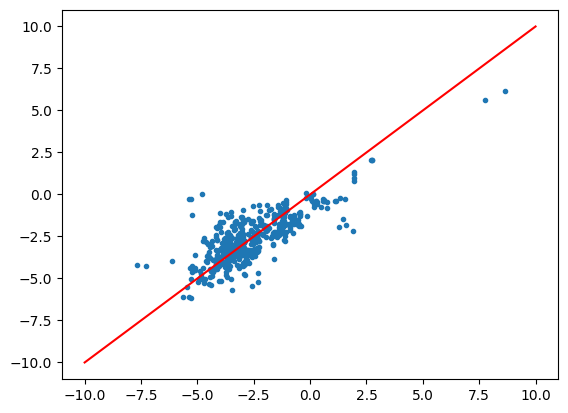

In [50]:
plt.plot(selected_labels, selected_outputs, '.')
plt.plot( [-10, 10],[-10, 10], 'red' )
# plt.xlim(-0.1, 0.1)
# plt.ylim(-0.1, 0.1)

## Quality of prediction: closest points

#### Creating df with means of classes

In [54]:
elements_names = [el.split('_')[0] for el in inds_colnames]

In [57]:
train_val_df.shape

(1932, 8)

In [65]:
train_val_df = pd.DataFrame(y_train)
train_val_df.columns = elements_names
train_val_df.insert(0, 'Sample_id', list(train_order) + list(val_order))
train_val_df.reset_index(drop=True, inplace=True)

In [66]:
mean_df = train_val_df[['Sample_id']]

for name in elements_names:
    mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
    mean_df.drop_duplicates('Sample_id', inplace=True)
    
# for name in elements_names:
#     mean_sd_df[name + '_sd'] = train_val_data_normalized_df.groupby('Sample_id')[name].transform(np.std)
#     mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
mean_df.sort_values(by='Sample_id', inplace=True)
mean_df.reset_index(drop=True, inplace=True)

/tmp/ipykernel_3805/4209521825.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_3805/4209521825.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_3805/4209521825.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guid

#### Checking if there is any chance wor it to work: if in test set classes in y_test are close to means of classes in train_val set

In [67]:
elements_names = [el.split('_')[0] for el in inds_colnames]

In [69]:
y_test_df = pd.DataFrame(y_test)
y_test_df.columns = elements_names
y_test_df.insert(0, 'Sample_id', test_order)
y_test_df.reset_index(drop=True, inplace=True)

In [70]:
closest = []
for i in range(y_test_df.shape[0]):
    closest.append((abs(y_test_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin())

In [71]:
len(closest)

483

In [72]:
y_test_df['Closest'] = closest

In [73]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0]

438

In [74]:
438/483

0.906832298136646

Looks resonably: for around 90% of cases in y, the class from X with the nearest mean is the actual y's class.

#### Now let's check if it works for the linear regression's output.

In [75]:
outputs = trained_model.predict(X_test)

In [76]:
outputs.shape

(483, 8)

In [77]:
outputs_df = pd.DataFrame(outputs)
outputs_df.columns = elements_names
outputs_df.insert(0, 'Real sample_id', test_order)
outputs_df.reset_index(drop=True, inplace=True)

In [78]:
closest = []
for i in range(outputs_df.shape[0]):
    closest.append((abs(outputs_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin())

In [79]:
len(closest)

483

In [80]:
outputs_df['Closest'] = closest

In [81]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0]

101

Around 1/3, poor.

## Quality of prediction: confidence intervals

In [83]:
outputs = trained_model.predict(X_test)

In [84]:
elements_names = [el.split('_')[0] for el in inds_colnames]

In [90]:
all_data_df = pd.DataFrame(y_train)
all_data_df = pd.concat([all_data_df,  
                        pd.DataFrame(y_test)])
all_data_df.columns = elements_names
all_data_df.insert(0, 'Sample_id', list(train_order) + list(val_order) + list(test_order))
all_data_df.reset_index(drop=True, inplace=True)

In [91]:
min_max_df = all_data_df[['Sample_id']]

for name in elements_names:
    min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    min_max_df[name + '_min'] = all_data_df.groupby('Sample_id')[name].transform('min')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
    
min_max_df.sort_values(by='Sample_id', inplace=True)
min_max_df.reset_index(drop=True, inplace=True)

max_df = min_max_df.iloc[:,1:(1+len(elements_names))]
min_df = min_max_df.iloc[:,1+len(elements_names):]

/tmp/ipykernel_3805/4042430873.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
/tmp/ipykernel_3805/4042430873.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_3805/4042430873.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/sta

In [92]:
mean_sd_df = all_data_df[['Sample_id']]

for name in elements_names:
    mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    mean_sd_df[name + '_sd'] = all_data_df.groupby('Sample_id')[name].transform(np.std)
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
mean_sd_df.sort_values(by='Sample_id', inplace=True)
mean_sd_df.reset_index(drop=True, inplace=True)

upper_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values + \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
upper_bound_df = pd.DataFrame(upper_bound_df, columns=elements_names)
lower_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values - \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
lower_bound_df = pd.DataFrame(lower_bound_df, columns=elements_names)

/tmp/ipykernel_3805/3639753013.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_3805/3639753013.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_3805/3639753013.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

In [94]:
min_max_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater_than_min = test_example > np.array(min_df.iloc[sample_id,:])
    
    less_than_max = test_example < np.array(max_df.iloc[sample_id,:])
    
    res = np.logical_and(greater_than_min, less_than_max)
    
    #print(res)
    min_max_res_list.append(res)

In [95]:
sd_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater = test_example > np.array(lower_bound_df.iloc[sample_id,:])
    
    less = test_example < np.array(upper_bound_df.iloc[sample_id,:])
    
    res = np.logical_and(greater, less)
    
    #print(res)
    sd_res_list.append(res)

In [96]:
elements_names

['Al', 'S', 'Cr', 'Mn', 'Co', 'Cu', 'Zn', 'Pb']

In [97]:
np.array(sd_res_list).mean()

0.343944099378882

In [98]:
np.array(sd_res_list).mean(0)

array([0.45134576, 0.41200828, 0.33954451, 0.29192547, 0.22981366,
       0.31469979, 0.2815735 , 0.43064182])

In [99]:
np.array(min_max_res_list).mean(0)

array([0.38923395, 0.38716356, 0.29399586, 0.25465839, 0.19047619,
       0.29606625, 0.25258799, 0.37888199])

In [100]:
np.array(min_max_res_list).mean()

0.3053830227743271

In [101]:
np.array(min_max_res_list).mean(0)

array([0.38923395, 0.38716356, 0.29399586, 0.25465839, 0.19047619,
       0.29606625, 0.25258799, 0.37888199])

In [90]:
%matplotlib notebook

In [102]:
outputs.shape

(483, 8)

In [103]:
%matplotlib notebook

<IPython.core.display.Javascript object>


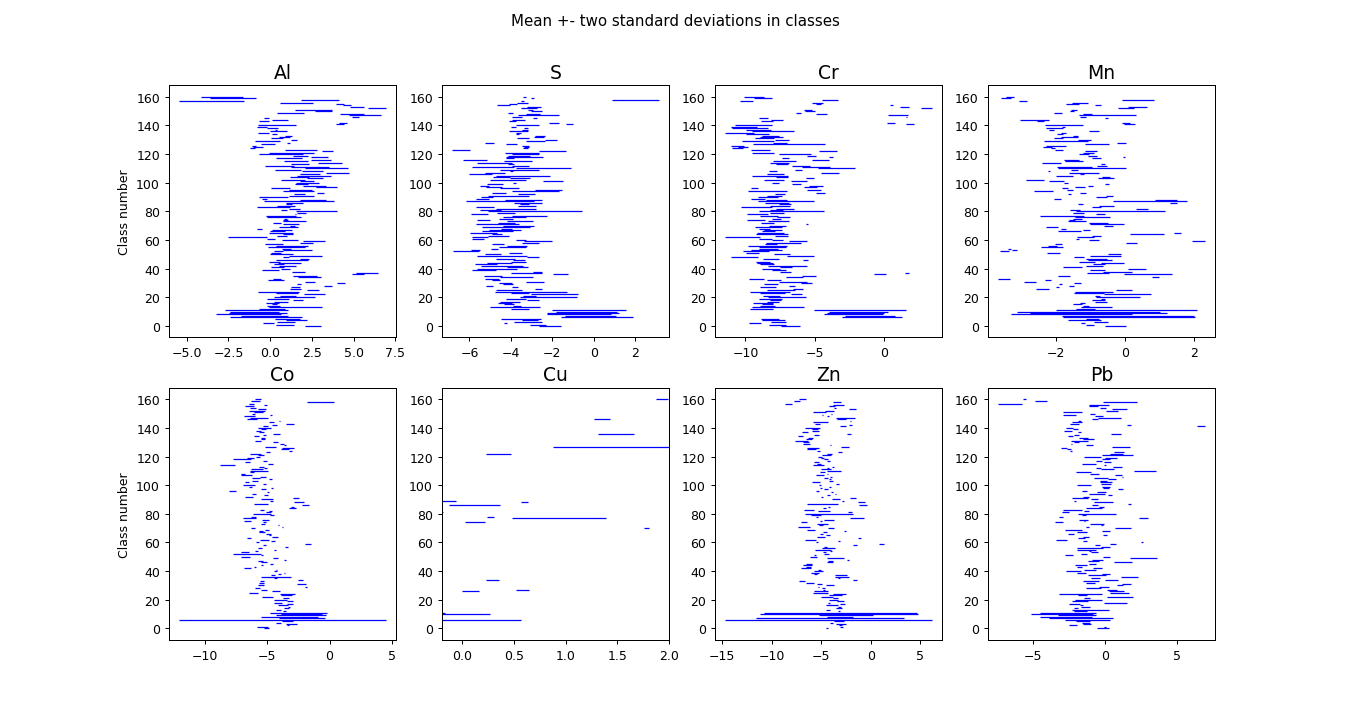

In [104]:
fig, ax = plt.subplots(2,4, figsize=(15,8))
plt.suptitle('Mean +- two standard deviations in classes')
for sample_id in range(min_max_df.shape[0]):
    for element in range(int((min_max_df.shape[1]-1)/2)):
        ax[element//4][element%4].hlines(y=sample_id, xmin=lower_bound_df.iloc[sample_id, element], 
                  xmax=upper_bound_df.iloc[sample_id, element], 
                  color="blue", linewidth=1)
        ax[element//4][element%4].set_title(elements_names[element], size=15)
        if element == 5:
            ax[element//4][element%4].set_xlim([-0.2, 2.0])
        if element == 0 or element == 4:
            ax[element//4][element%4].set_ylabel('Class number')
#plt.savefig(figures_path + 'intervals.png', dpi=300)

<IPython.core.display.Javascript object>


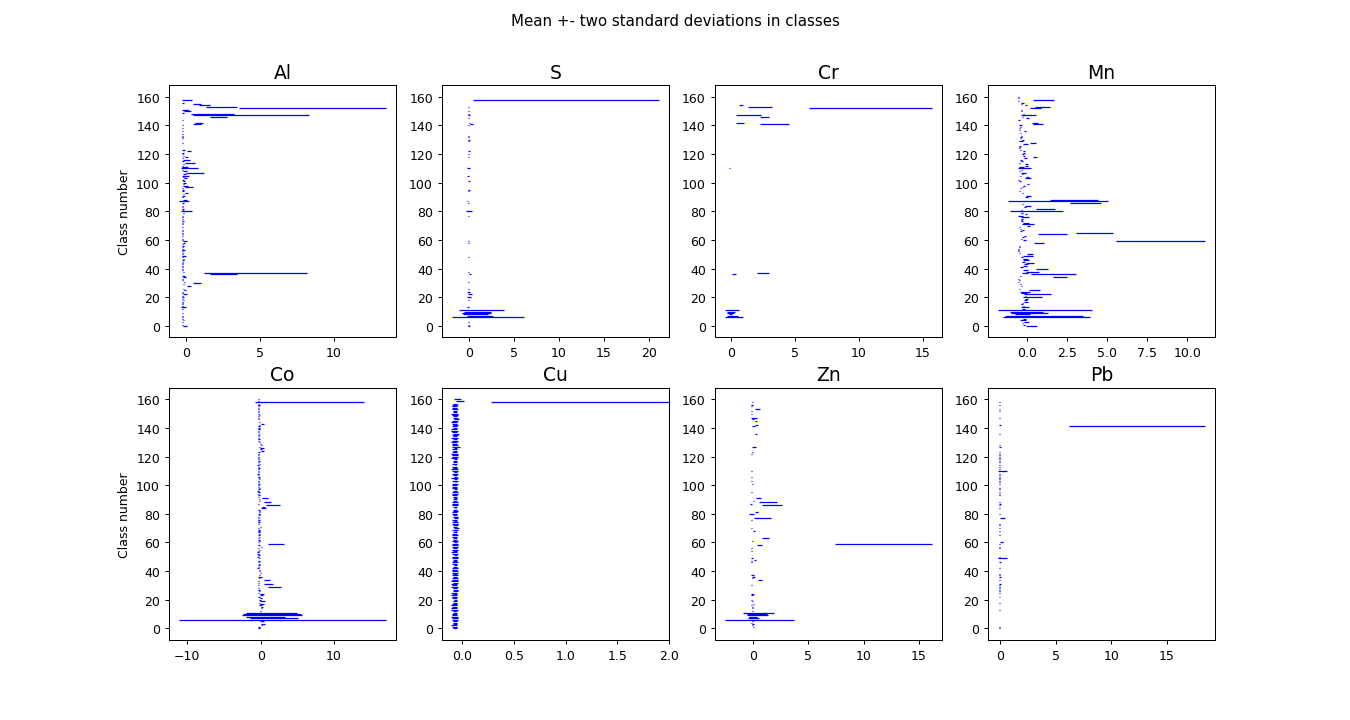

In [111]:
fig, ax = plt.subplots(2,4, figsize=(15,8))
plt.suptitle('Mean +- two standard deviations in classes')
for sample_id in range(min_max_df.shape[0]):
    for element in range(int((min_max_df.shape[1]-1)/2)):
        ax[element//4][element%4].hlines(y=sample_id, xmin=lower_bound_df.iloc[sample_id, element], 
                  xmax=upper_bound_df.iloc[sample_id, element], 
                  color="blue", linewidth=1)
        ax[element//4][element%4].set_title(elements_names[element], size=15)
        if element == 5:
            ax[element//4][element%4].set_xlim([-0.2, 2.0])
        if element == 0 or element == 4:
            ax[element//4][element%4].set_ylabel('Class number')
#plt.savefig(figures_path + 'intervals.png', dpi=300)

<IPython.core.display.Javascript object>


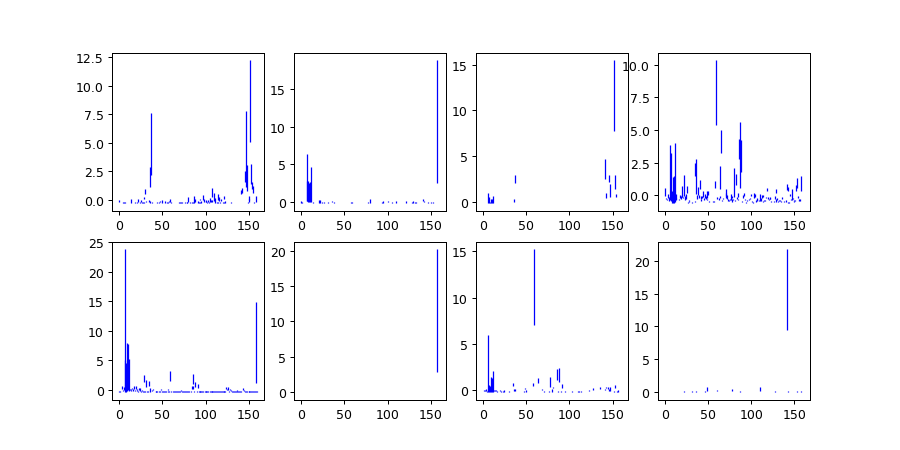

In [104]:
fig, ax = plt.subplots(2,4, figsize=(10,5))
for sample_id in range(min_max_df.shape[0]):
    for element in range(int((min_max_df.shape[1]-1)/2)):
        ax[element//4][element%4].vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
                  ymax=min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)
        #ax[element%4][element%2].set_title(elements_names[element])

<IPython.core.display.Javascript object>


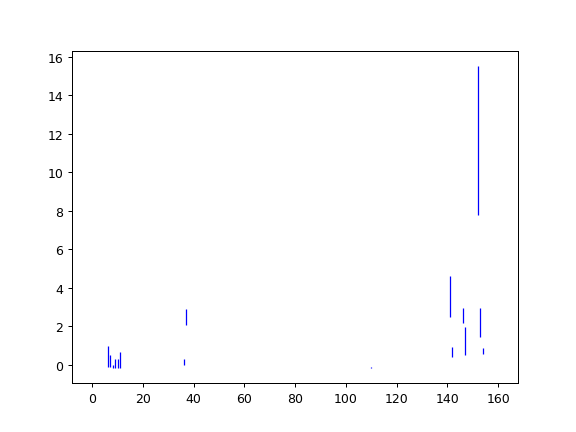

In [108]:
element = 3
for sample_id in range(min_max_df.shape[0]):
    plt.vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
                  ymax=min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)

In [ ]:
inside_min_max_interval = torch.cat([res.unsqueeze(0) for res in res_list])

In [ ]:
(inside_min_max_interval*1.0).mean(axis=0)

In [48]:
(inside_min_max_interval*1.0).mean(axis=0) #best weights: 1/2, 1/4, 1/8, 1/40, ...

tensor([0.2854, 0.3729, 0.0542, 0.0729, 0.0625, 0.0500, 0.0125, 0.2188],
       device='cuda:0')

In [44]:
from_sample.mean(axis=0)

tensor([ 5.0448, -0.1901,  5.1446, -0.1243, -0.5578,  0.0341, -0.1956,  0.1323],
       device='cuda:0')

In [46]:
from_sample.std(axis=0)

tensor([0.7062, 0.0081, 0.2986, 0.0153, 0.0049, 0.0180, 0.0018, 0.0793],
       device='cuda:0')

(array([2., 1., 0., 4., 3., 2., 0., 0., 2., 1.]),
 array([0.0093034 , 0.03666412, 0.06402484, 0.09138557, 0.11874629,
        0.146107  , 0.17346773, 0.20082845, 0.22818917, 0.25554991,
        0.28291062]),
 <BarContainer object of 10 artists>)

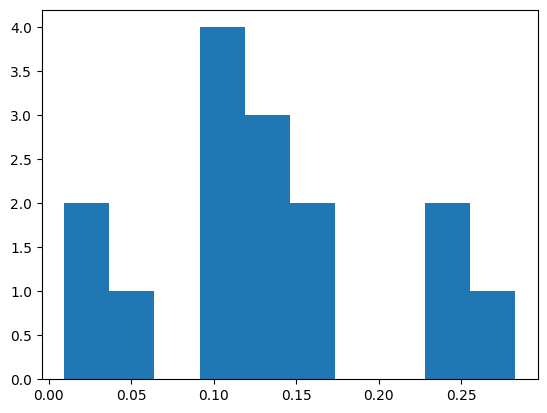

In [67]:
plt.hist(np.array(from_sample[:,7].cpu()))

## Interpretability

...